Script générant un attaque adverse simple : rotation. On test soit :

- Tout les angles pour toutes les images pour obtenir une accuracy moyenne du réseaux sur un data set en fonction de l'angle
- Tout les angle pour chaque image pour un label donné pour obtenir les angles maximisant ou minimisant la prediction d'un réseau sur ce label

--- TODO : ---

> Simplifier un peu le code et l'adapter au nouveaux réseaux 


In [1]:
from retinotopy import *

Welcome on Linux-6.5.0-1019-oem-x86_64-with-glibc2.35
CONEC-LID-001
Running on GPU :  NVIDIA RTX A2000 12GB #GPU= 1
On date 2024-04-25, Running learning on host CONEC-LID-001 with device cuda


In [2]:
args = Params()
args.folders = ['val']
args.do_rotation = True
args

Params(datetag='2024-04-25', loader='/data/JNJER/Deep_learning/data/Imagenet_urls_ILSVRC_2016.json', folders=['val'], image_size=224, num_epochs=5, n_train_stop=0, seed=1998, batch_size=50, batch_size_val=50, lr=0.00015, momentum=0.06, beta2=0, rs_min=0.05, rs_max=-4.95, do_polar=True, do_rotation=True)

# Rotating a whole dataset by 45° :

data_set_type='full'
--------------------------------------------------
args.do_polar=True
Loaded 50001 images under val


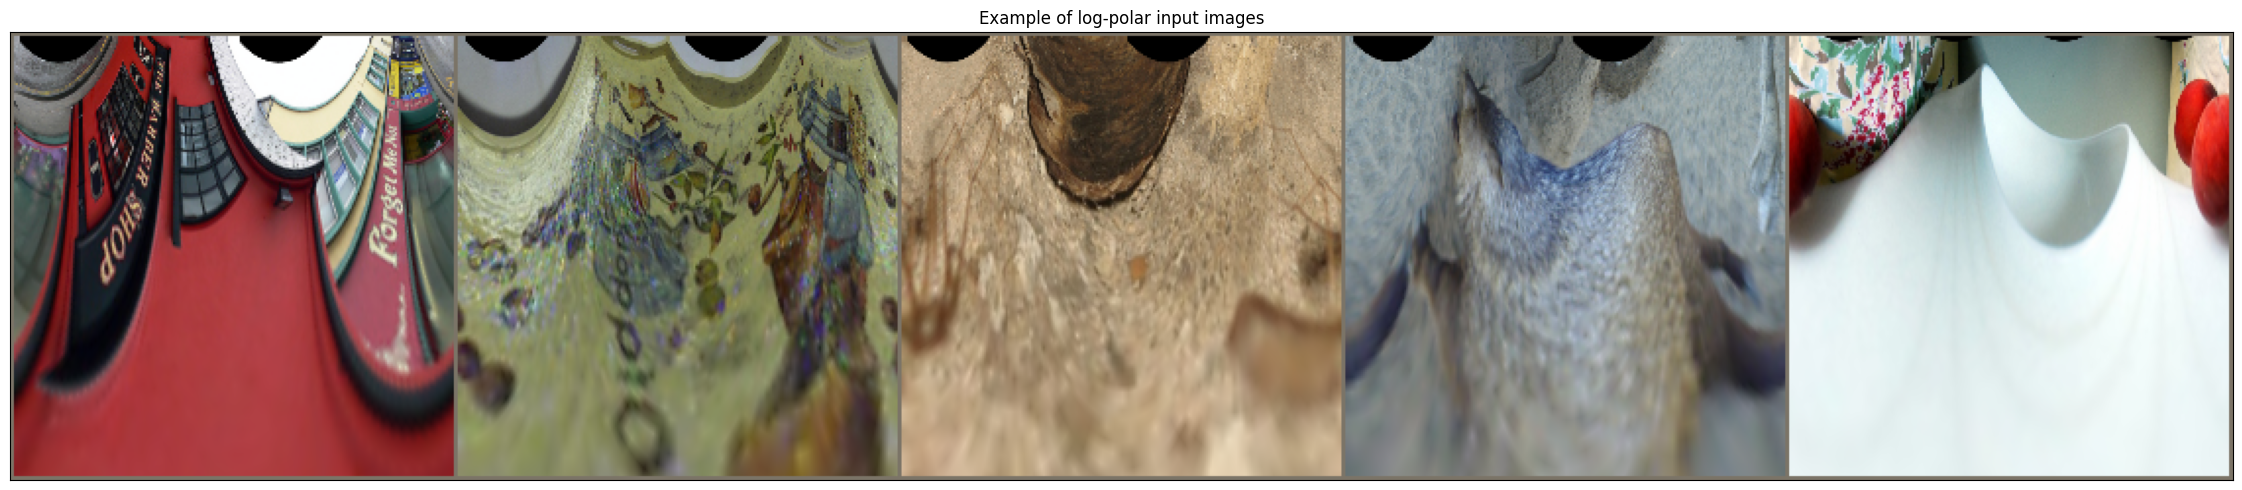

args.do_polar=False
Loaded 50001 images under val


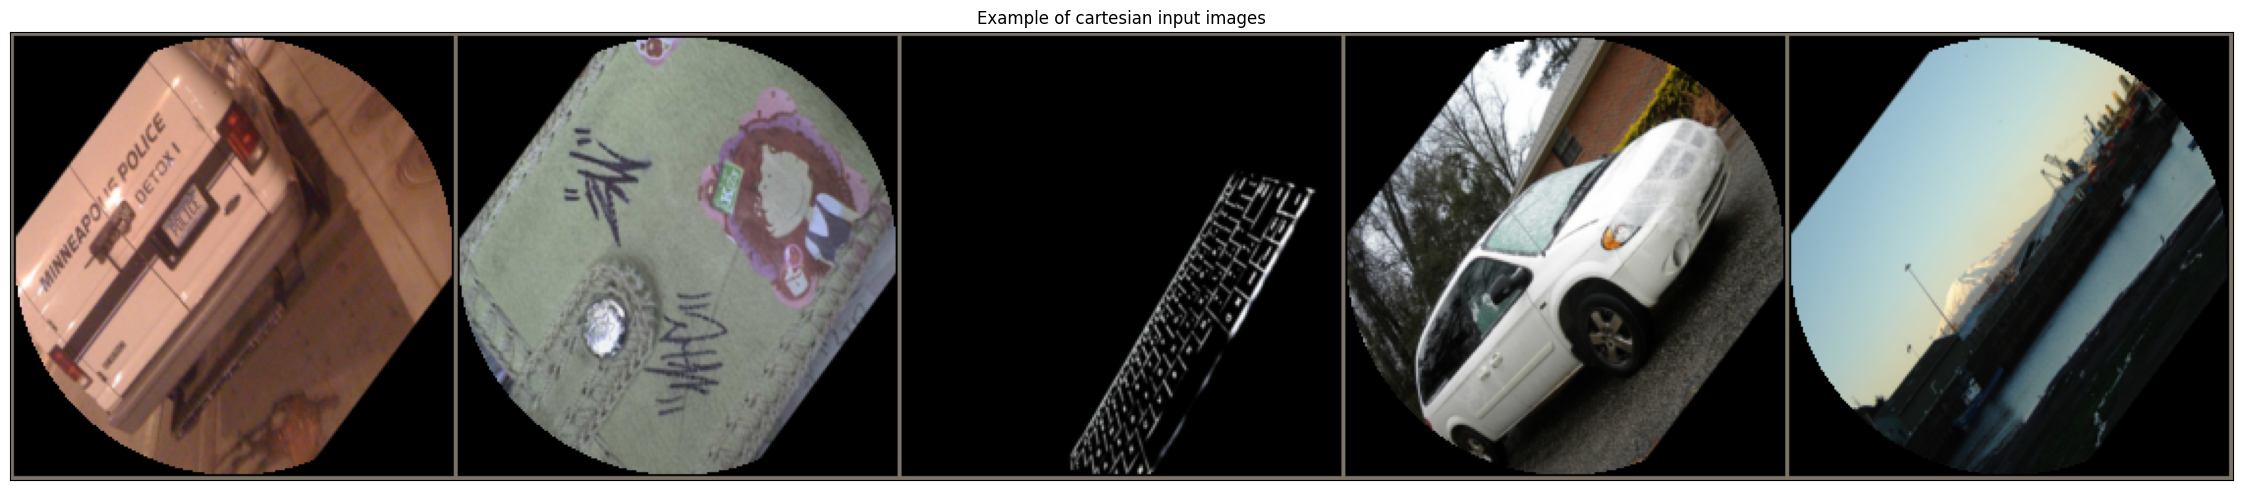

data_set_type='boxes'
--------------------------------------------------
args.do_polar=True
Loaded 50025 images under val


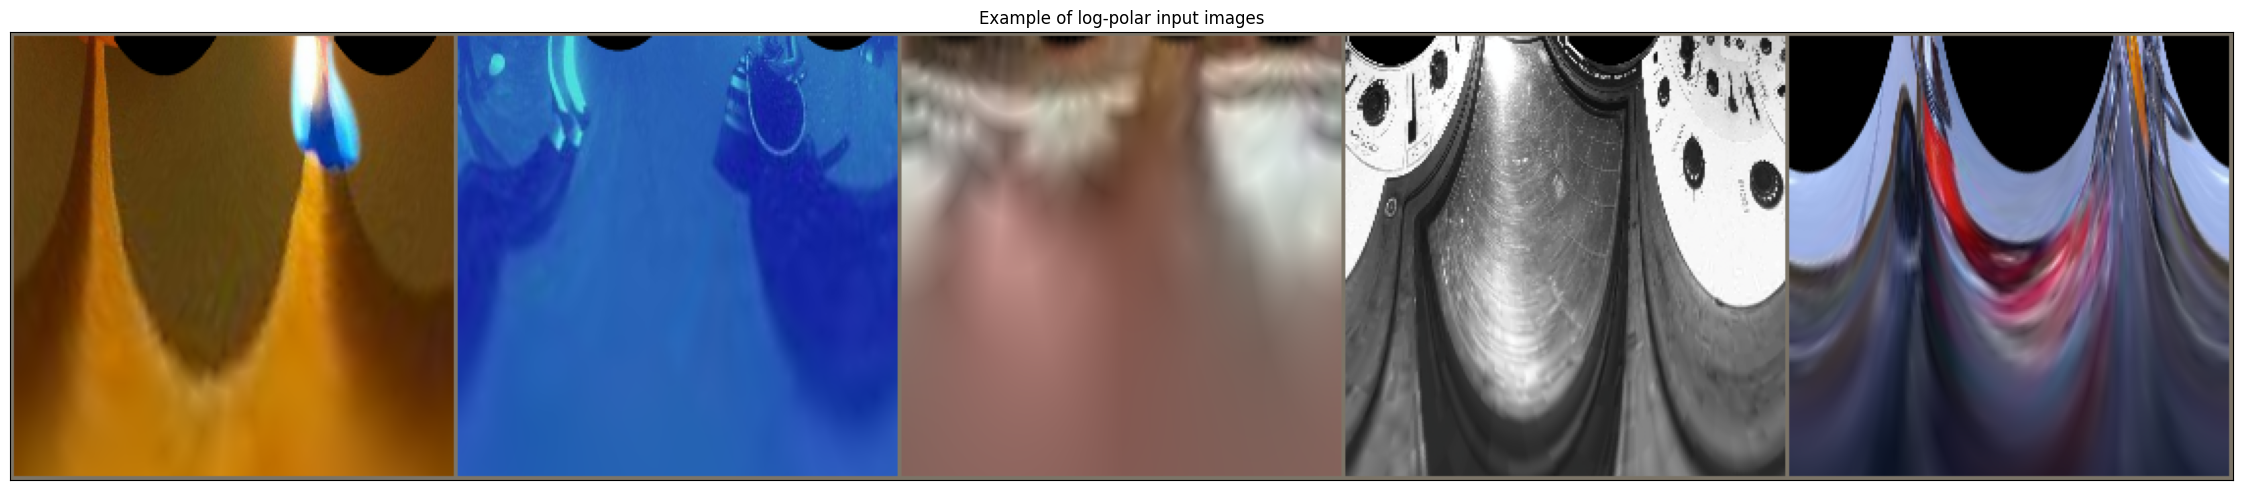

args.do_polar=False
Loaded 50025 images under val


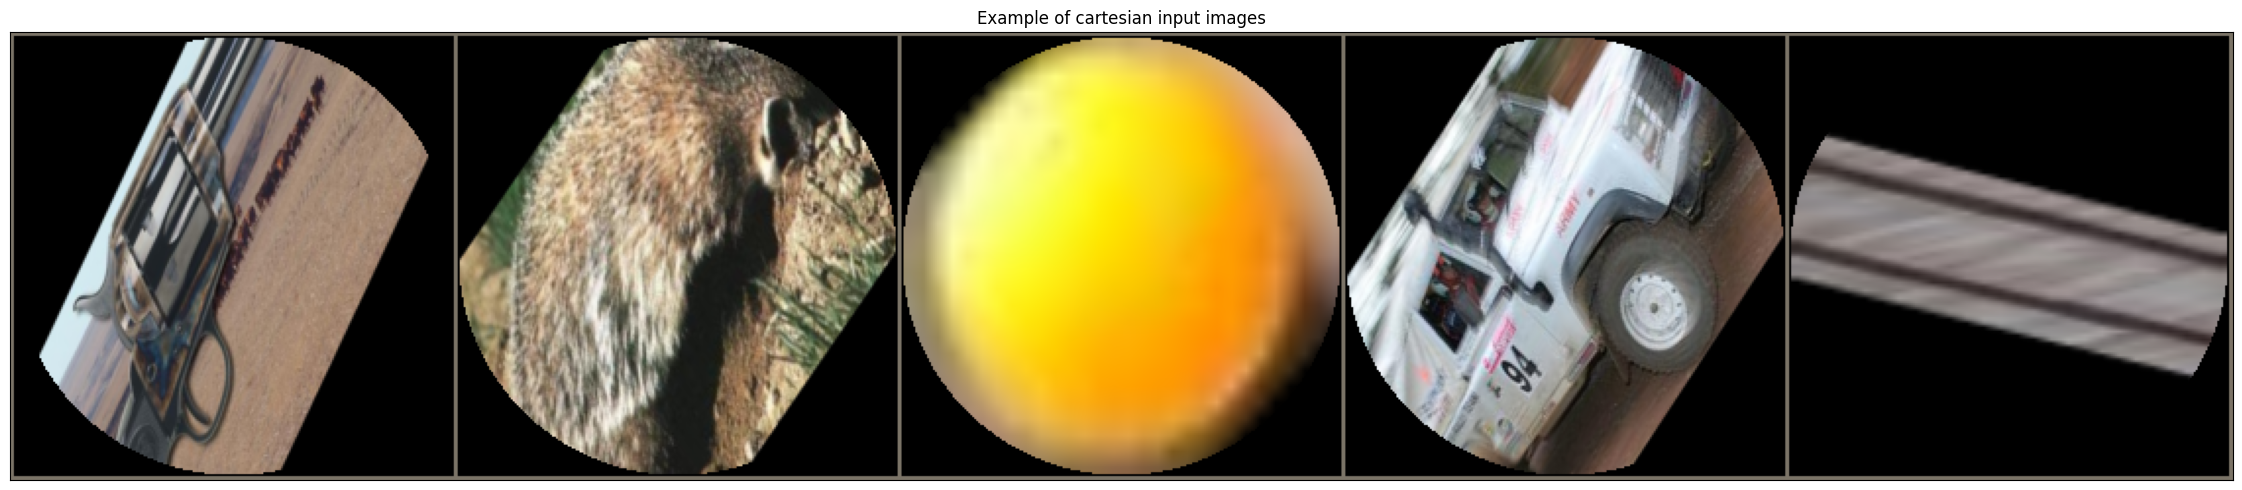

data_set_type='focus'
--------------------------------------------------
args.do_polar=True
Loaded 49981 images under val


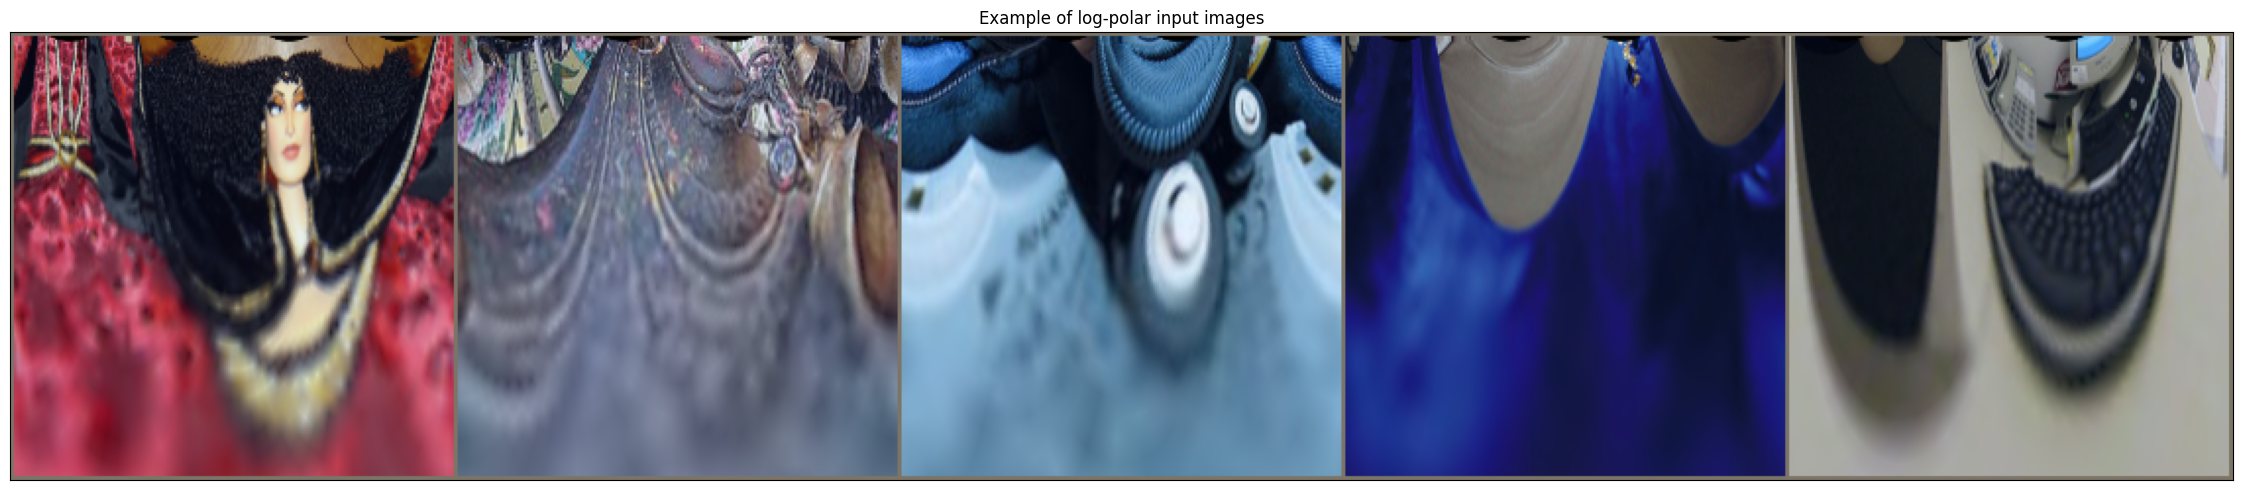

args.do_polar=False
Loaded 49981 images under val


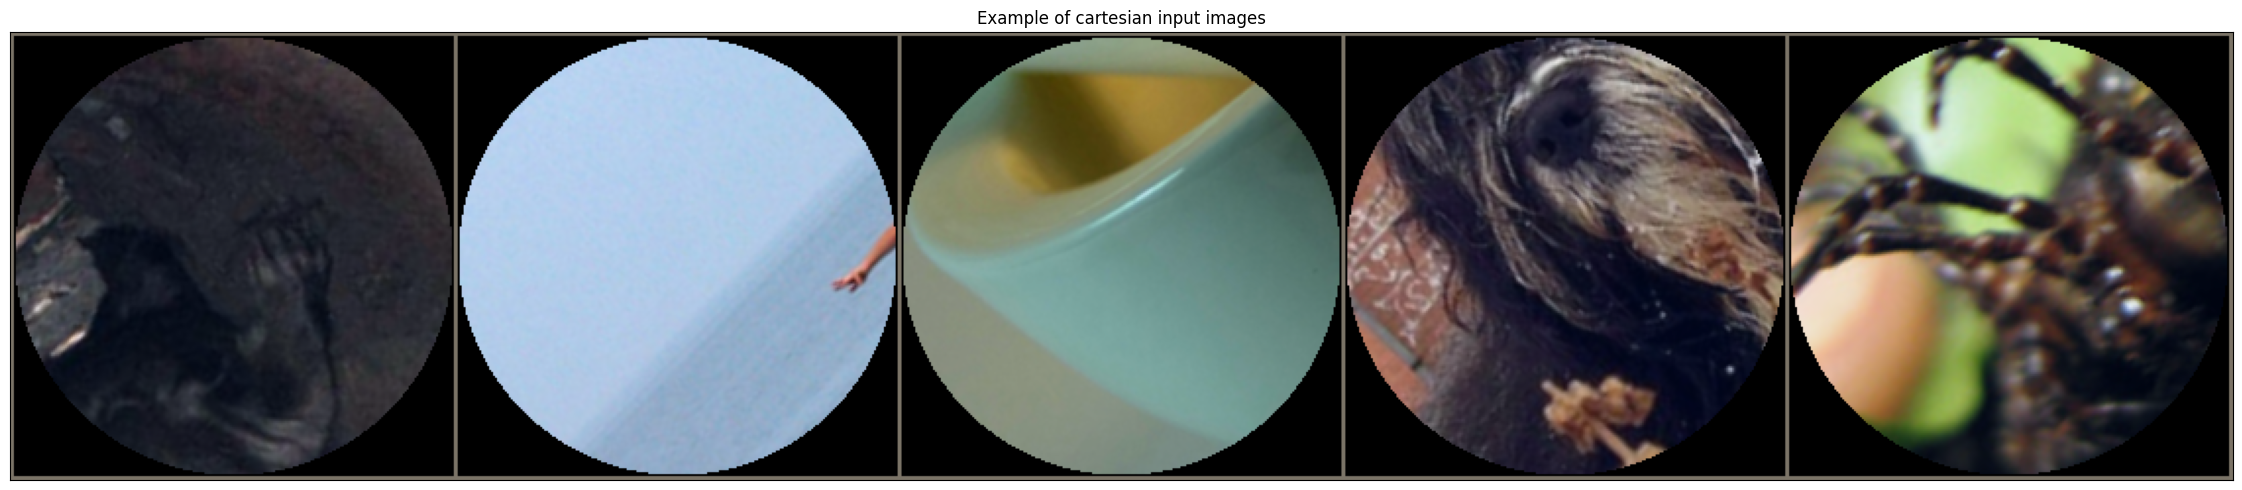

In [3]:
data_set_types = ['full', 'boxes', 'focus', ]

for data_set_type in data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images to perform the training
    print(50*'-')

    for args.do_polar in [True, False]:
        print(f'{args.do_polar=}')
        dataloaders = datasets_transforms(args, angle_min=44, angle_max=46)
        for _, (images, labels) in enumerate(dataloaders['val']):
            images, labels = images.to('cpu'), labels.to('cpu')
            break
        imshow(images[:5], title='Example of cartesian input images' if not(args.do_polar) else 'Example of log-polar input images', fig_height=5)
        plt.show()
    print(50*'=')

# testing each networkfor different rotations

In [4]:
filename = f'{data_cache}/{datetag}_results_test-rotations.json'

print(f'{filename=}')
angles = np.linspace(-180, 180, 24, endpoint=False)
delta_angle = angles[1] - angles[0]
angles_min = angles - delta_angle/2
angles_max = angles + delta_angle/2

# Loading and testing the networks
for data_set_type in data_set_types:
    
    print(50*'=')
    print(f'{data_set_type=}')
    args = Params()
    args.folders = ['val']
    args.do_rotation = True
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images to perform the training
    print(50*'-')
        
    for model_name, lw in  zip(['resnet101', 'resnet50', 'resnet18'], [4, 2, 1]): #, 
        for do_polar, color in zip([True, False], ['b', 'r']):
            print(50*'.')
            filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_test-rotations.json'
            if os.path.isfile(filename):
                df_angle = pd.read_json(filename)
            else:
                results = np.zeros((0, 3))
                filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}'
                json_filename = filename + '.json'
                model_filename = filename + '.pt'

                if os.path.isfile(model_filename):
                    print(f"Loading pre-trained resnet {model_filename}")
                    model = charge_model(model_filename).to(device).eval()

                    for angle, angle_min, angle_max in zip(angles, angles_min, angles_max):
                        dataloaders = datasets_transforms(args, angle_min=angle_min, angle_max=angle_max,shuffle=False)
                        with torch.no_grad():
                            acc_val = 0
                            n_val = len(dataloaders['val'])
                            for i_image, (images, labels) in enumerate(dataloaders['val']):
                                images, labels = images.to(device), labels.to(device)

                                outputs = model(images)

                                _, preds = torch.max(outputs.data, dim=1)
                                detect = (preds == labels.data).cpu().numpy()

                                results = np.vstack((results, np.vstack([i_image*args.batch_size_val + np.arange(args.batch_size_val), angle*np.ones(args.batch_size_val), detect]).T))
                            
                df_angle = pd.DataFrame(results, columns=['i_image', 'angle', 'accuracy'])     
                df_angle.to_json(filename)                        

    print(50*'=')

filename='cached_data/2024-04-25_results_test-rotations.json'
data_set_type='full'
--------------------------------------------------
..................................................
..................................................
..................................................
..................................................
..................................................
..................................................
data_set_type='boxes'
--------------------------------------------------
..................................................
..................................................
..................................................
..................................................
..................................................
..................................................
Loading pre-trained resnet cached_data/2024-04-25_boxes_resnet18_do_polar=False.pt
loading .... cached_data/2024-04-25_boxes_resnet18_do_polar=False.pt
Loaded 50025 images under val

In [ ]:
i_image*args.batch_size_val + np.arange(args.batch_size_val), angle*np.ones(args.batch_size_val), detect

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
 array([-180., -180., -180., -180., -180., -180., -180., -180., -180.,
        -180., -180., -180., -180., -180., -180., -180., -180., -180.,
        -180., -180., -180., -180., -180., -180., -180., -180., -180.,
        -180., -180., -180., -180., -180., -180., -180., -180., -180.,
        -180., -180., -180., -180., -180., -180., -180., -180., -180.,
        -180., -180., -180., -180., -180.]),
 array([False, False, False,  True, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True, False, False,  True, False,  True,  True, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True, False,  True,
        False, Fals

In [ ]:
results = np.zeros((0, 3))

In [ ]:
np.vstack([i_image*args.batch_size_val + np.arange(args.batch_size_val), angle*np.ones(args.batch_size_val), detect]).T

array([[   0., -180.,    0.],
       [   1., -180.,    0.],
       [   2., -180.,    0.],
       [   3., -180.,    1.],
       [   4., -180.,    0.],
       [   5., -180.,    0.],
       [   6., -180.,    0.],
       [   7., -180.,    0.],
       [   8., -180.,    0.],
       [   9., -180.,    0.],
       [  10., -180.,    0.],
       [  11., -180.,    0.],
       [  12., -180.,    0.],
       [  13., -180.,    0.],
       [  14., -180.,    0.],
       [  15., -180.,    0.],
       [  16., -180.,    0.],
       [  17., -180.,    0.],
       [  18., -180.,    1.],
       [  19., -180.,    0.],
       [  20., -180.,    0.],
       [  21., -180.,    1.],
       [  22., -180.,    0.],
       [  23., -180.,    1.],
       [  24., -180.,    1.],
       [  25., -180.,    0.],
       [  26., -180.,    0.],
       [  27., -180.,    0.],
       [  28., -180.,    0.],
       [  29., -180.,    0.],
       [  30., -180.,    0.],
       [  31., -180.,    0.],
       [  32., -180.,    0.],
       [  

In [ ]:
results = np.vstack((results, np.vstack([i_image*args.batch_size_val + np.arange(args.batch_size_val), angle*np.ones(args.batch_size_val), detect]).T))

In [ ]:
results.shape


(100, 3)

In [ ]:
preds, (preds == labels.data).cpu()

(tensor([134, 112, 154,   0,  89, 245, 130, 108,  88, 815, 117,   7, 108, 108, 108, 108, 117, 108,   0,   7, 254,   0,   1,   0,   0, 108,
         351,  23, 102, 334, 117, 153, 971,  88, 102, 296, 203,  51, 109, 254, 108, 117,   0, 117,   0, 286,  84, 102, 108, 103],
        device='cuda:0'),
 tensor([False, False, False,  True, False, False, False, False, False, False, False, False, False, False, False, False, False, False,  True,
         False, False,  True, False,  True,  True, False, False, False, False, False, False, False, False, False, False, False, False, False,
         False, False, False, False,  True, False,  True, False, False, False, False, False]))

In [ ]:
i_image
detect = (preds == labels.data).cpu().numpy()

In [ ]:
i_image

0

In [ ]:
df_angle

,angle,accuracy
0,12,0.5


filename='cached_data/2024-04-25_focus_resnet18_do_polar=False'


KeyError: 'model'

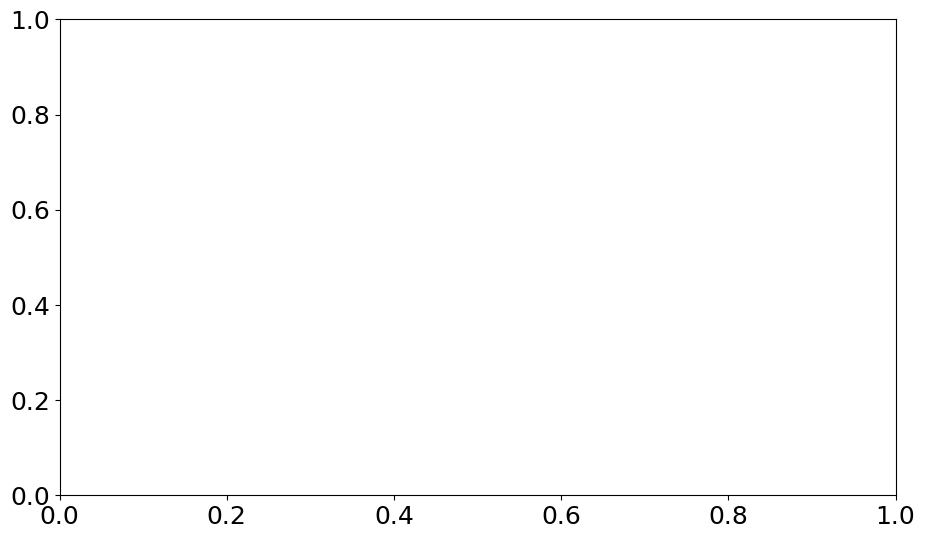

In [ ]:
print(f'{filename=}')
angles = np.arange(-180, 181, 15)
verbose = False

if os.path.isfile(filename):
    df_angle = pd.read_json(filename)
    
    
fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))


colors = ['brown', 'royalblue',  'orange', 'lightsteelblue']

labels = {'cached_data/2024-01-16_resnet101_do_polar=False.pt':'Resnet101 Cartesian', 'cached_data/2024-01-16_resnet101_do_polar=True.pt':'Resnet101 Retinotopic'}

for i, model_name in enumerate(['cached_data/2024-01-16_resnet101_do_polar=False.pt', 'cached_data/2024-01-16_resnet101_do_polar=True.pt']):
    if 'vgg' in model_name:
        ax = df_angle[(df_angle['model']==model_name)].plot(x="var", y="mean_prediction", color=colors[i],
                                                         marker='x', lw=2, label=labels[model_name], ax=ax)
    else:
        ax = df_angle[(df_angle['model']==model_name)].plot(x="var", y="mean_prediction", color=colors[i],
                                                         marker='o', lw=2, label=labels[model_name], ax=ax)
    print(f'Mean for {model_name}', np.mean(df_angle[(df_angle['model']==model_name)]['mean_prediction']))
    print(f'Std for {model_name}', np.std(df_angle[(df_angle['model']==model_name)]['mean_prediction']))


#ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xlim(-5, 185)
ax.set_ylim(0, 1)


ax.axvline(x=0, c='k', ls='--', lw=1)
plt.axvline(x=90, c='k', ls='--', lw=1)
plt.axvline(x=180, c='k', ls='--', lw=1)
ax.set_xticks([0, 90, 180])
#ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
#ax.set_yticks([.7, .75, .8])
ax.set_ylabel('Average Accuracy', font=font)
ax.set_xlabel('Rotation angle (°)', font=font)
plt.legend(bbox_to_anchor=(0.8, 1), loc='upper center', fontsize=10, edgecolor='none')
plt.tight_layout()
# plt.xticks(font=font)
# plt.yticks(font=font);


In [ ]:
# datetag = strftime("%Y-%m-%d", gmtime())
datetag = '2023-04-11'
datetag = '2023-06-08'


#filename = f'cached_data/{datetag}_results_10k_rot_eval.json'
filename = f'cached_data/2024-03-11_results_rotate_test_do_rotation=False.json'

print(f'{filename=}')
angles = np.arange(-180, 181, 15)
verbose = False

if os.path.isfile(filename):
    df_angle = pd.read_json(filename)
    
    
fig, ax = plt.subplots(figsize=(fig_width*phi/3, fig_width/phi/2))


colors = ['brown', 'royalblue',  'orange', 'lightsteelblue']

labels = {'resnet101_False':'Resnet101 Cartesian', 'resnet101_True':'Resnet101 Retinotopic'}

for i, model_name in enumerate(['resnet101_False', 'resnet101_True']):
    if 'vgg' in model_name:
        ax = df_angle[(df_angle['model']==model_name)].plot(x="var", y="mean_prediction", color=colors[i],
                                                         marker='x', lw=2, label=labels[model_name], ax=ax)
    else:
        ax = df_angle[(df_angle['model']==model_name)].plot(x="var", y="mean_prediction", color=colors[i],
                                                         marker='o', lw=2, label=labels[model_name], ax=ax)
    print(f'Mean for {model_name}', np.mean(df_angle[(df_angle['model']==model_name)]['mean_prediction']))
    print(f'Std for {model_name}', np.std(df_angle[(df_angle['model']==model_name)]['mean_prediction']))


#ax.hlines(xmin=-185, xmax=185, y=1/2, ls='--', ec='gray')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xlim(-5, 185)
ax.set_ylim(0, 1)


ax.axvline(x=0, c='k', ls='--', lw=1)
plt.axvline(x=90, c='k', ls='--', lw=1)
plt.axvline(x=180, c='k', ls='--', lw=1)
ax.set_xticks([0, 90, 180])
#ax.set_yscale("logit", use_overline=True) #one_half="1/2", 
#ax.set_yticks([.7, .75, .8])
ax.set_ylabel('Average Accuracy', font=font)
ax.set_xlabel('Rotation angle (°)', font=font)
plt.legend(bbox_to_anchor=(0.8, 1), loc='upper center', fontsize=10, edgecolor='none')
plt.tight_layout()
# plt.xticks(font=font)
# plt.yticks(font=font);


In [ ]:
df